# 01. Species Identification

Reproduces and visualises the species identification analysis from Lee et al. (2023).

**Methods reproduced:**
- Average Nucleotide Identity (ANI) heatmap — Figure 2 reproduction
- Species boundary validation (ANI ≥ 96% cutoff)
- Strain overview summary

**Extended analysis:**
- Interactive ANI heatmap (Plotly) — hover to inspect pairwise values
- Species-level ANI summary statistics

**Reference:** Lee et al. (2023), *Frontiers in Microbiology*, 14:1175304  
**Data:** FastANI results, NCBI BioProject PRJNA877469

In [1]:
# ── dependencies ──────────────────────────────────────────────
# pip install pandas numpy seaborn matplotlib plotly scipy

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

PROC = Path('../data/processed')
RAW  = Path('../data/raw')

print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load data

In [2]:
# ── ANI matrix (ANIclustermap order = Figure 2 order) ─────────
ani = pd.read_csv(RAW / 'ANIclustermap_matrix.tsv', sep='\t', index_col=None)
ani.index = ani.columns.tolist()
print(f'ANI matrix: {ani.shape}')   # 30 × 30

# ── strain metadata ───────────────────────────────────────────
meta = pd.read_csv(PROC / 'strain_metadata.csv')
print(f'Strain metadata: {len(meta)} isolates')

# ── species annotation for all 30 strains in ANI matrix ───────
# 22 isolates + 8 reference strains
species_map = {
    # 22 isolates
    'LJP441'  : 'A. salmonicida',
    'OY59'    : 'A. salmonicida',
    'OY56'    : 'A. salmonicida',
    'SU2'     : 'A. salmonicida',
    'SL21'    : 'A. salmonicida',
    'SC45'    : 'A. salmonicida',
    'SL19'    : 'A. salmonicida',
    'LJP308'  : 'A. piscicola',
    'SL22'    : 'A. bestiarum',
    'SU6'     : 'A. bestiarum',
    'SU58-3'  : 'A. bestiarum',
    'OY52'    : 'A. media',
    'SU15'    : 'A. rivipollensis',
    'SU3'     : 'A. rivipollensis',
    'SU9'     : 'A. rivipollensis',
    'A539'    : 'A. rivipollensis',
    'SC42'    : 'A. rivipollensis',
    'OY1'     : 'A. rivipollensis',
    'SU4'     : 'A. caviae',
    'A537'    : 'A. hydrophila',
    'A533'    : 'A. dhakensis',
    'A536'    : 'A. dhakensis',
    # 8 reference strains
    'A.salmonicida_NCTC12959'  : 'A. salmonicida (ref)',
    'A.piscicola_LMG24783'     : 'A. piscicola (ref)',
    'A.bestiarum_CECT4227'     : 'A. bestiarum (ref)',
    'A.media_CECT4232'         : 'A. media (ref)',
    'A.rivipollensis_KN_Mc_11N1': 'A. rivipollensis (ref)',
    'A.caviae_NCTC12244'       : 'A. caviae (ref)',
    'A.hydrophila_ATCC7966'    : 'A. hydrophila (ref)',
    'A.dhakensis_CIP107500'    : 'A. dhakensis (ref)',
}

# color palette — 8 species
species_palette = {
    'A. salmonicida'      : '#E07B54',
    'A. piscicola'        : '#5B8DB8',
    'A. bestiarum'        : '#6BAF92',
    'A. media'            : '#9B7BB8',
    'A. rivipollensis'    : '#D4A843',
    'A. caviae'           : '#C4706A',
    'A. hydrophila'       : '#7BA87B',
    'A. dhakensis'        : '#8AA6C4',
    # references use same color, slightly muted
    'A. salmonicida (ref)': '#E07B54',
    'A. piscicola (ref)'  : '#5B8DB8',
    'A. bestiarum (ref)'  : '#6BAF92',
    'A. media (ref)'      : '#9B7BB8',
    'A. rivipollensis (ref)': '#D4A843',
    'A. caviae (ref)'     : '#C4706A',
    'A. hydrophila (ref)' : '#7BA87B',
    'A. dhakensis (ref)'  : '#8AA6C4',
}

# row colors for clustermap
row_colors = pd.Series(
    [species_palette.get(species_map.get(s, 'Unknown'), '#CCCCCC')
     for s in ani.index],
    index=ani.index
)

print('Species map loaded — 30 strains annotated')

ANI matrix: (30, 30)
Strain metadata: 22 isolates
Species map loaded — 30 strains annotated


---
## 2. ANI heatmap — Figure 2 reproduction (seaborn)

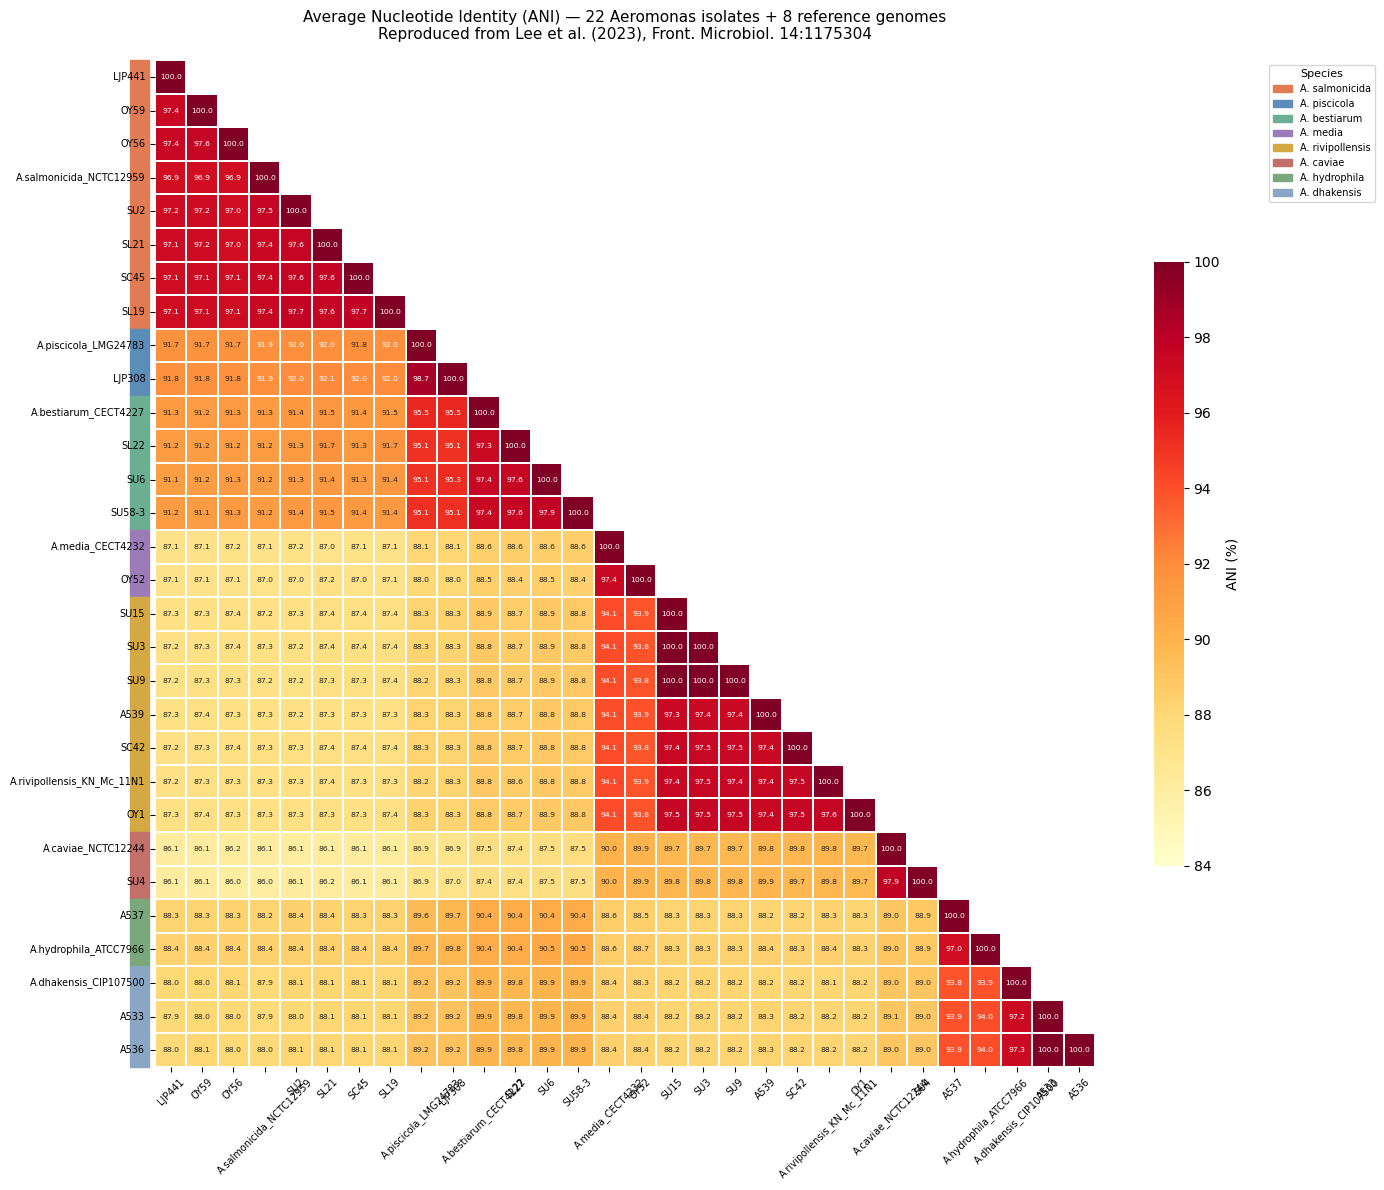

Figure saved: fig2_ani_heatmap.png


In [3]:
# ── static clustermap (seaborn) ───────────────────────────────
# mask upper triangle for cleaner look
mask = np.triu(np.ones_like(ani.values, dtype=bool), k=1)

# fill masked values with NaN for display
ani_lower = ani.copy().astype(float)
ani_lower.values[mask] = np.nan

fig, ax = plt.subplots(figsize=(14, 12))

# draw heatmap without clustering (ANIclustermap already clustered)
sns.heatmap(
    ani_lower,
    ax=ax,
    cmap='YlOrRd',
    vmin=84,
    vmax=100,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 5.5},
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'ANI (%)', 'shrink': 0.6}
)

# add species color bar on left
for i, strain in enumerate(ani.index):
    color = species_palette.get(species_map.get(strain, 'Unknown'), '#CCCCCC')
    ax.add_patch(plt.Rectangle(
        (-0.8, i), 0.6, 1,
        color=color, clip_on=False, transform=ax.transData
    ))

ax.set_title(
    'Average Nucleotide Identity (ANI) — 22 Aeromonas isolates + 8 reference genomes\n'
    'Reproduced from Lee et al. (2023), Front. Microbiol. 14:1175304',
    fontsize=11, pad=15
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7, rotation=0)

# legend
unique_species = [
    'A. salmonicida', 'A. piscicola', 'A. bestiarum', 'A. media',
    'A. rivipollensis', 'A. caviae', 'A. hydrophila', 'A. dhakensis'
]
handles = [
    mpatches.Patch(color=species_palette[sp], label=sp)
    for sp in unique_species
]
ax.legend(handles=handles, title='Species', bbox_to_anchor=(1.18, 1),
          loc='upper left', fontsize=7, title_fontsize=8, frameon=True)

plt.tight_layout()
plt.savefig('../data/processed/fig2_ani_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig2_ani_heatmap.png')

---
## 3. Interactive ANI heatmap (Plotly) — extended

In [5]:
# ── interactive heatmap (Plotly) ──────────────────────────────
# hover shows: strain pair + ANI value + species of each

strains = ani.index.tolist()
z_vals  = ani.values.astype(float)

# custom hover text
hover_text = []
for i, s_row in enumerate(strains):
    row_hover = []
    for j, s_col in enumerate(strains):
        val  = z_vals[i, j]
        sp_r = species_map.get(s_row, 'Unknown').replace(' (ref)', '')
        sp_c = species_map.get(s_col, 'Unknown').replace(' (ref)', '')
        same_sp_label = "<span style='color:green'>Same species (≥96%)</span>" if val >= 96 and i != j else ""
        row_hover.append(
            f'<b>{s_row}</b> ({sp_r})<br>'
            f'<b>{s_col}</b> ({sp_c})<br>'
            f'ANI: <b>{val:.2f}%</b><br>'
            f'{same_sp_label}'
)
    hover_text.append(row_hover)

# species color annotations for axis labels
label_colors = [
    species_palette.get(species_map.get(s, 'Unknown'), '#333333')
    for s in strains
]

fig = go.Figure(data=go.Heatmap(
    z=z_vals,
    x=strains,
    y=strains,
    colorscale='YlOrRd',
    zmin=84,
    zmax=100,
    text=hover_text,
    hoverinfo='text',
    colorbar=dict(title='ANI (%)', thickness=15)
))

fig.update_layout(
    title=dict(
        text='ANI Matrix — Aeromonas isolates + reference genomes<br>'
             '<sup>Hover over cells to inspect pairwise ANI values</sup>',
        font_size=13
    ),
    width=900, height=850,
    xaxis=dict(tickangle=45, tickfont=dict(size=9)),
    yaxis=dict(tickfont=dict(size=9), autorange='reversed'),
    margin=dict(l=120, b=120)
)

fig.show()

---
## 4. Species boundary validation (ANI ≥ 96%)

In [6]:
# ── ANI species boundary analysis ─────────────────────────────
# same species pairs should show ANI ≥ 96%
# Colston et al. (2014): 96% cutoff for Aeromonas

ANI_CUTOFF = 96.0

records = []
for i, s1 in enumerate(ani.index):
    for j, s2 in enumerate(ani.columns):
        if i >= j:   # upper triangle only, skip diagonal
            continue
        val  = ani.loc[s1, s2]
        sp1  = species_map.get(s1, 'Unknown').replace(' (ref)', '')
        sp2  = species_map.get(s2, 'Unknown').replace(' (ref)', '')
        same = (sp1 == sp2)
        records.append({
            'strain_1'    : s1,
            'strain_2'    : s2,
            'species_1'   : sp1,
            'species_2'   : sp2,
            'ANI'         : val,
            'same_species': same,
            'above_cutoff': val >= ANI_CUTOFF
        })

ani_pairs = pd.DataFrame(records)

# identical strain pairs (ANI ≥ 99.9%) — paper mentions A533/A536 and SU3/SU9/SU15
identical = ani_pairs[ani_pairs['ANI'] >= 99.9].sort_values('ANI', ascending=False)
print('=== Identical strain pairs (ANI ≥ 99.9%) ===')
print(identical[['strain_1', 'strain_2', 'species_1', 'ANI']].to_string(index=False))

print()

# cross-species pairs above cutoff (would indicate misclassification)
cross_above = ani_pairs[
    (~ani_pairs['same_species']) & (ani_pairs['above_cutoff'])
]
print(f'=== Cross-species pairs above {ANI_CUTOFF}% cutoff ===')
if len(cross_above) == 0:
    print('None — all species boundaries are clean')
else:
    print(cross_above[['strain_1', 'strain_2', 'species_1', 'species_2', 'ANI']].to_string(index=False))

print()

# same-species pairs below cutoff (would indicate misclassification)
same_below = ani_pairs[
    ani_pairs['same_species'] & (~ani_pairs['above_cutoff']) &
    (ani_pairs['ANI'] > 0)
]
print(f'=== Same-species pairs below {ANI_CUTOFF}% cutoff ===')
if len(same_below) == 0:
    print('None — all same-species pairs confirm species assignment')
else:
    print(same_below[['strain_1', 'strain_2', 'species_1', 'ANI']].to_string(index=False))

=== Identical strain pairs (ANI ≥ 99.9%) ===
strain_1 strain_2        species_1       ANI
    A533     A536     A. dhakensis 99.999214
     SU3      SU9 A. rivipollensis 99.997955
    SU15      SU9 A. rivipollensis 99.996124
    SU15      SU3 A. rivipollensis 99.994522

=== Cross-species pairs above 96.0% cutoff ===
None — all species boundaries are clean

=== Same-species pairs below 96.0% cutoff ===
None — all same-species pairs confirm species assignment


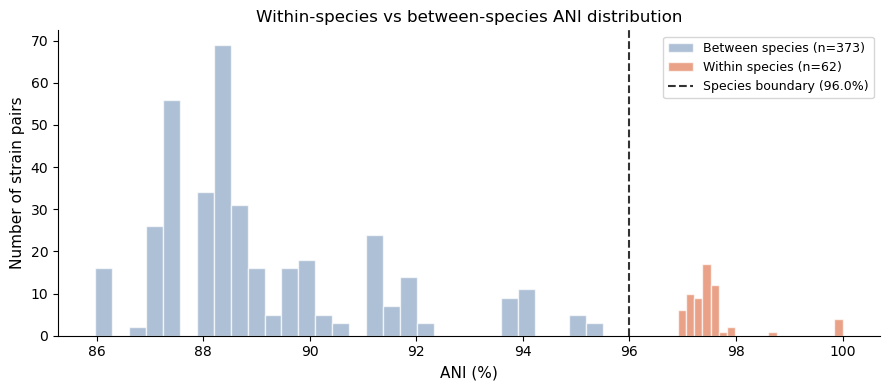

Figure saved: fig_ani_distribution.png


In [7]:
# ── within vs between species ANI distribution ────────────────
fig, ax = plt.subplots(figsize=(9, 4))

same_vals    = ani_pairs[ani_pairs['same_species']]['ANI']
diff_vals    = ani_pairs[~ani_pairs['same_species']]['ANI']

ax.hist(diff_vals, bins=30, alpha=0.7, color='#8AA6C4',
        label=f'Between species (n={len(diff_vals)})', edgecolor='white')
ax.hist(same_vals, bins=20, alpha=0.7, color='#E07B54',
        label=f'Within species (n={len(same_vals)})', edgecolor='white')

ax.axvline(ANI_CUTOFF, color='#333333', linestyle='--', linewidth=1.5,
           label=f'Species boundary ({ANI_CUTOFF}%)')

ax.set_xlabel('ANI (%)', fontsize=11)
ax.set_ylabel('Number of strain pairs', fontsize=11)
ax.set_title('Within-species vs between-species ANI distribution', fontsize=12)
ax.legend(fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig('../data/processed/fig_ani_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_ani_distribution.png')

---
## 5. Strain overview summary

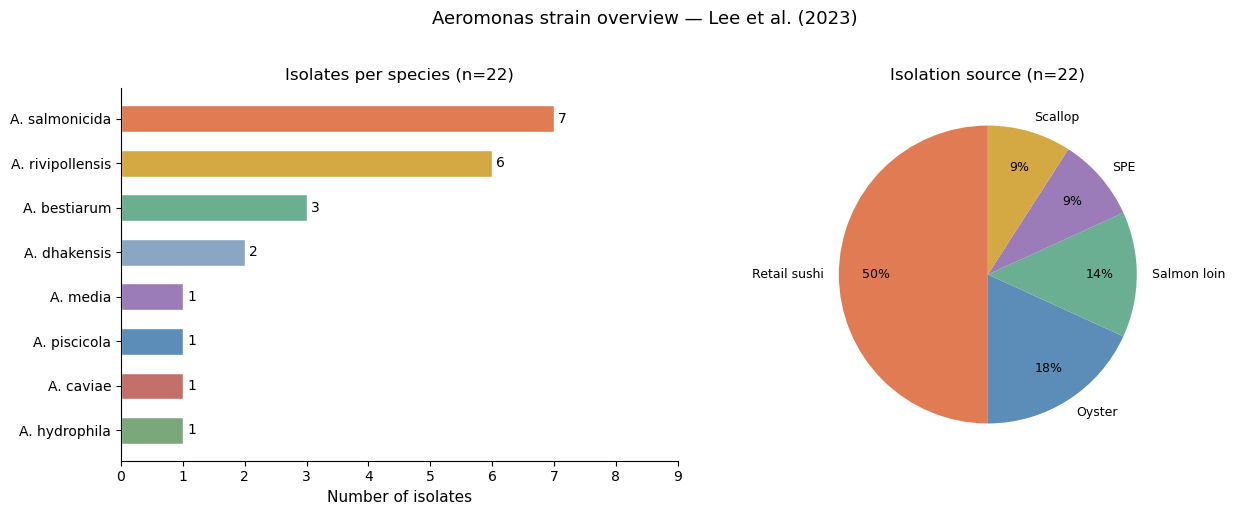

Figure saved: fig_strain_overview.png


In [8]:
# ── isolate count per species ─────────────────────────────────
isolate_species = {
    k: v for k, v in species_map.items() if '(ref)' not in v
}
species_counts = pd.Series(isolate_species).value_counts().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: bar chart ───────────────────────────────────────────
colors = [species_palette[sp] for sp in species_counts.index]
bars = axes[0].barh(species_counts.index, species_counts.values,
                    color=colors, edgecolor='white', height=0.6)
axes[0].bar_label(bars, padding=3, fontsize=10)
axes[0].set_xlabel('Number of isolates', fontsize=11)
axes[0].set_title('Isolates per species (n=22)', fontsize=12)
axes[0].set_xlim(0, species_counts.max() + 2)
sns.despine(ax=axes[0])

# ── right: isolation source breakdown ─────────────────────────
source_map = {
    'LJP441': 'SPE', 'LJP308': 'SPE',
    'OY59': 'Oyster', 'OY56': 'Oyster', 'OY52': 'Oyster', 'OY1': 'Oyster',
    'SL19': 'Salmon loin', 'SL21': 'Salmon loin', 'SL22': 'Salmon loin',
    'SC42': 'Scallop', 'SC45': 'Scallop',
    'SU2' : 'Retail sushi', 'SU3': 'Retail sushi', 'SU4': 'Retail sushi',
    'SU6' : 'Retail sushi', 'SU9': 'Retail sushi', 'SU15': 'Retail sushi',
    'SU58-3': 'Retail sushi',
    'A533': 'Retail sushi', 'A536': 'Retail sushi',
    'A537': 'Retail sushi', 'A539': 'Retail sushi',
}
source_counts = pd.Series(source_map).value_counts()
source_colors = ['#E07B54', '#5B8DB8', '#6BAF92', '#9B7BB8', '#D4A843']

wedges, texts, autotexts = axes[1].pie(
    source_counts.values,
    labels=source_counts.index,
    colors=source_colors[:len(source_counts)],
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 9}
)
axes[1].set_title('Isolation source (n=22)', fontsize=12)

plt.suptitle('Aeromonas strain overview — Lee et al. (2023)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/fig_strain_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_strain_overview.png')

In [9]:
# ── summary table ─────────────────────────────────────────────
summary_rows = []
for strain, species in isolate_species.items():
    summary_rows.append({
        'Strain ID'       : strain,
        'Species'         : species,
        'Isolation source': source_map.get(strain, 'Unknown'),
        'NCBI accession'  : meta.set_index('strain_id')['accession'].get(strain, '—')
    })

summary_df = pd.DataFrame(summary_rows).sort_values(['Species', 'Strain ID'])
summary_df.to_csv(PROC / 'strain_summary.csv', index=False)
print(f'strain_summary.csv saved — {len(summary_df)} strains')
print()
print(summary_df.to_string(index=False))

strain_summary.csv saved — 22 strains

Strain ID          Species Isolation source  NCBI accession
     SL22     A. bestiarum      Salmon loin JAOPLV000000000
   SU58-3     A. bestiarum     Retail sushi JAOPLL000000000
      SU6     A. bestiarum     Retail sushi               —
      SU4        A. caviae     Retail sushi               —
     A533     A. dhakensis     Retail sushi JAOPLS000000000
     A536     A. dhakensis     Retail sushi JAOPLR000000000
     A537    A. hydrophila     Retail sushi JAOPLQ000000000
     OY52         A. media           Oyster JAOPLG000000000
   LJP308     A. piscicola              SPE               —
     A539 A. rivipollensis     Retail sushi JAOPLP000000000
      OY1 A. rivipollensis           Oyster JAOPLH000000000
     SC42 A. rivipollensis          Scallop JAOPLF000000000
     SU15 A. rivipollensis     Retail sushi JAOPLI000000000
      SU3 A. rivipollensis     Retail sushi JAOPLK000000000
      SU9 A. rivipollensis     Retail sushi JAOPLJ000000000
 